In [1]:
import uproot
file=uproot.open(r"C:\Users\Agastya\Hbb-jet-tagging\data\raw\train_rooot_file.root")
file

<ReadOnlyDirectory '/' at 0x02325fa4d640>

In [2]:
file.keys()

['deepntuplizer;1', 'deepntuplizer/tree;42', 'deepntuplizer/tree;41']

In [3]:
file.classnames()

{'deepntuplizer;1': 'TDirectory',
 'deepntuplizer/tree;42': 'TTree',
 'deepntuplizer/tree;41': 'TTree'}

In [4]:
file["deepntuplizer/tree;42"]
file["deepntuplizer/tree;41"]

<TTree 'tree' (219 branches) at 0x02325fdb36e0>

In [5]:
file.classnames()

{'deepntuplizer;1': 'TDirectory',
 'deepntuplizer/tree;42': 'TTree',
 'deepntuplizer/tree;41': 'TTree'}

In [6]:
file["deepntuplizer/tree;42"].all_members

{'@fUniqueID': 0,
 '@fBits': 50331656,
 'fName': 'tree',
 'fTitle': 'tree',
 'fLineColor': 602,
 'fLineStyle': 1,
 'fLineWidth': 1,
 'fFillColor': 0,
 'fFillStyle': 1001,
 'fMarkerColor': 1,
 'fMarkerStyle': 1,
 'fMarkerSize': 1.0,
 'fEntries': 200000,
 'fTotBytes': 2224438754,
 'fZipBytes': 1210756095,
 'fSavedBytes': 1209010162,
 'fFlushedBytes': 1209010162,
 'fWeight': 1.0,
 'fTimerInterval': 0,
 'fScanField': 25,
 'fUpdate': 0,
 'fDefaultEntryOffsetLen': 1000,
 'fNClusterRange': 0,
 'fMaxEntries': 1000000000000,
 'fMaxEntryLoop': 1000000000000,
 'fMaxVirtualSize': 0,
 'fAutoSave': 4871,
 'fAutoFlush': 4871,
 'fEstimate': 1000000,
 'fClusterRangeEnd': array([], dtype='>i8'),
 'fClusterSize': array([], dtype='>i8'),
 'fBranches': <TObjArray of 219 items at 0x02325f5defc0>,
 'fLeaves': <TObjArray of 219 items at 0x02325fdb33b0>,
 'fAliases': None}

In [7]:
tree=file["deepntuplizer/tree;41"]
tree.keys()
tree.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
Delta_gen_pt         | float                    | AsDtype('>f4')
event_no             | uint32_t                 | AsDtype('>u4')
gen_pt               | float                    | AsDtype('>f4')
isB                  | int32_t                  | AsDtype('>i4')
isBB                 | int32_t                  | AsDtype('>i4')
isC                  | int32_t                  | AsDtype('>i4')
isG                  | int32_t                  | AsDtype('>i4')
isLeptonicB          | int32_t                  | AsDtype('>i4')
isLeptonicB_C        | int32_t                  | AsDtype('>i4')
isS                  | int32_t                  | AsDtype('>i4')
isUD                 | int32_t                  | AsDtype('>i4')
isUndefined          | int32_t                  | AsDtype('>i4')
jet_corr_pt          | float                    | AsDtype(

In [8]:
import awkward as ak
import pandas as pd
import numpy as np

feature_cols = [
    
    "fj_pt",
    "fj_sdmass",    
    "fj_sdn2",
    "fj_n_sdsubjets",
    "fj_tau1",
    "fj_tau2",
    "fj_tau3",
    "fj_ptDR",
    "fj_relptdiff",
    "fj_jetNTracks",
    "fj_nSV",
    "fj_sdsj1_pt",
    "fj_sdsj1_mult",
    "fj_sdsj1_ptD",
    "fj_mass",
    "fj_eta",
    "fj_phi",
    "fj_sdsj1_eta",
    "fj_sdsj1_mass"
]
label_col = "label_H_bb"

arrays = tree.arrays(feature_cols + [label_col], library="np")
df=pd.DataFrame(arrays)
df.head()
df.insert(
    loc=7,
    column="tau21",
    value=df["fj_tau2"]/df["fj_tau1"]
)
df.insert(
    loc=8,
    column="tau32",
    value=df["fj_tau3"]/df["fj_tau2"]
)
df.head()






,fj_pt,fj_sdmass,fj_sdn2,fj_n_sdsubjets,fj_tau1,fj_tau2,fj_tau3,tau21,tau32,fj_ptDR,...,fj_nSV,fj_sdsj1_pt,fj_sdsj1_mult,fj_sdsj1_ptD,fj_mass,fj_eta,fj_phi,fj_sdsj1_eta,fj_sdsj1_mass,label_H_bb
0,448.633636,4.911332,0.000073,2.0,0.067988,0.059589,0.044930,0.876467,0.753994,11.378714,...,0.0,349.067657,6.0,0.525917,68.060570,-0.277724,-2.183877,-0.280709,3.302880,0
1,868.861389,34.992409,0.001675,2.0,0.111101,0.087648,0.072055,0.788904,0.822090,112.677155,...,0.0,699.895508,19.0,0.412773,161.474731,-0.716812,2.365500,-0.708606,19.311876,0
2,573.674377,13.481631,0.000554,2.0,0.073106,0.061262,0.049685,0.837985,0.811027,27.063063,...,1.0,404.355164,9.0,0.682750,86.054962,0.219193,0.296306,0.219143,6.023303,0
3,206.318527,18.484650,0.005919,2.0,0.132059,0.086257,0.064672,0.653168,0.749767,42.051800,...,2.0,176.024475,13.0,0.331445,35.347668,0.336462,2.244762,0.337573,11.302593,0
4,1068.199097,99.316536,0.012706,2.0,0.116926,0.040401,0.032547,0.345525,0.805614,195.188263,...,1.0,696.555420,19.0,0.360593,139.384796,0.889782,-2.385019,0.917607,22.814959,1


In [9]:

print("Any NaNs left?", df.isna().any().any())
print("Any inf left?", np.isinf(df.values).any())
print("Final dataset size:", len(df))


Any NaNs left? False
Any inf left? False
Final dataset size: 199711


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199711 entries, 0 to 199710
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   fj_pt           199711 non-null  float32
 1   fj_sdmass       199711 non-null  float32
 2   fj_sdn2         199711 non-null  float32
 3   fj_n_sdsubjets  199711 non-null  float32
 4   fj_tau1         199711 non-null  float32
 5   fj_tau2         199711 non-null  float32
 6   fj_tau3         199711 non-null  float32
 7   tau21           199711 non-null  float32
 8   tau32           199711 non-null  float32
 9   fj_ptDR         199711 non-null  float32
 10  fj_relptdiff    199711 non-null  float32
 11  fj_jetNTracks   199711 non-null  float32
 12  fj_nSV          199711 non-null  float32
 13  fj_sdsj1_pt     199711 non-null  float32
 14  fj_sdsj1_mult   199711 non-null  float32
 15  fj_sdsj1_ptD    199711 non-null  float32
 16  fj_mass         199711 non-null  float32
 17  fj_eta    

,count,mean,std,min,25%,50%,75%,max
fj_pt,199711.0,906.913147,748.722656,200.009521,394.399536,647.730713,1075.453918,5065.494629
fj_sdmass,199711.0,71.774101,101.896355,-0.506504,8.147754,35.351578,106.010765,1568.656250
fj_sdn2,199711.0,0.022973,0.042032,0.000000,0.000176,0.003046,0.026219,0.383772
fj_n_sdsubjets,199711.0,1.977538,0.181603,0.000000,2.000000,2.000000,2.000000,2.000000
fj_tau1,199711.0,0.134923,0.095930,0.002113,0.064109,0.109307,0.179103,0.652408
fj_tau2,199711.0,0.077197,0.047973,0.000990,0.041067,0.067078,0.102914,0.416016
fj_tau3,199711.0,0.061070,0.036491,0.000670,0.033017,0.054021,0.082281,0.290092
tau21,199711.0,0.636531,0.185552,0.038218,0.504292,0.671577,0.789235,0.987337
tau32,199711.0,0.802785,0.095176,0.080785,0.760404,0.822083,0.867230,1.149014
fj_ptDR,199711.0,152.794571,216.782776,0.000000,19.540759,79.013527,215.521919,3156.111084



Label counts:
label_H_bb
0    174993
1     24718
Name: count, dtype: int64

Label proportions:
label_H_bb
0    0.876231
1    0.123769
Name: proportion, dtype: float64


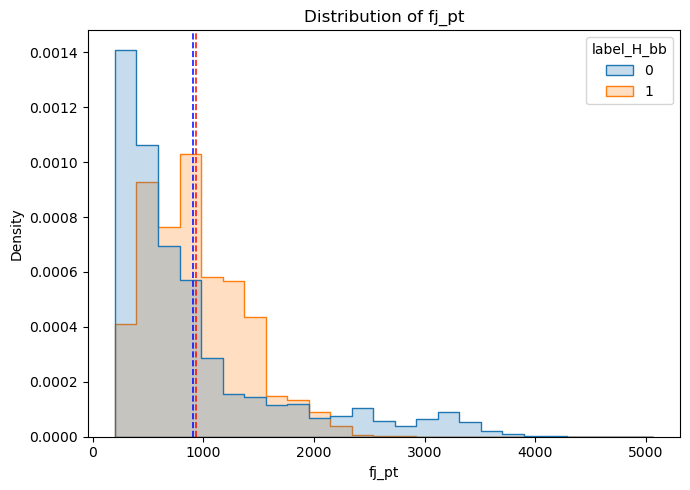

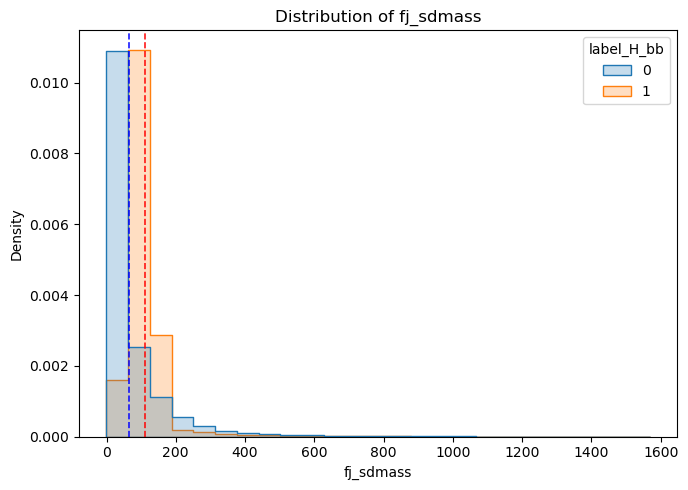

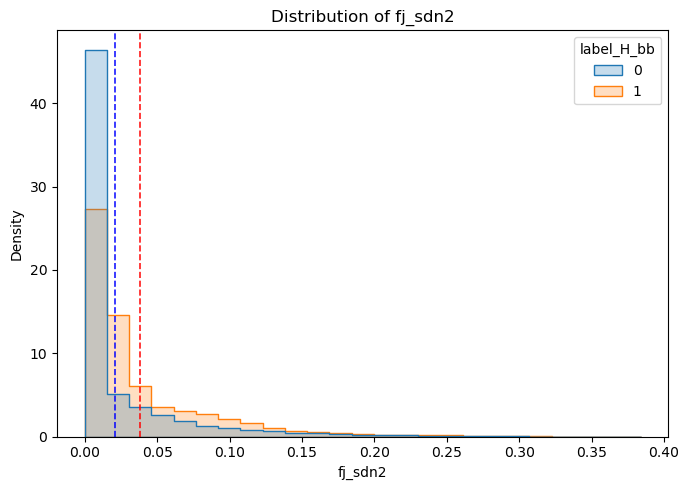

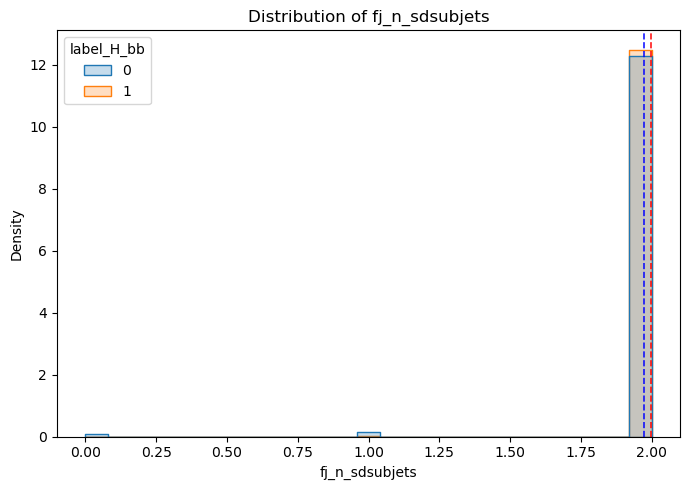

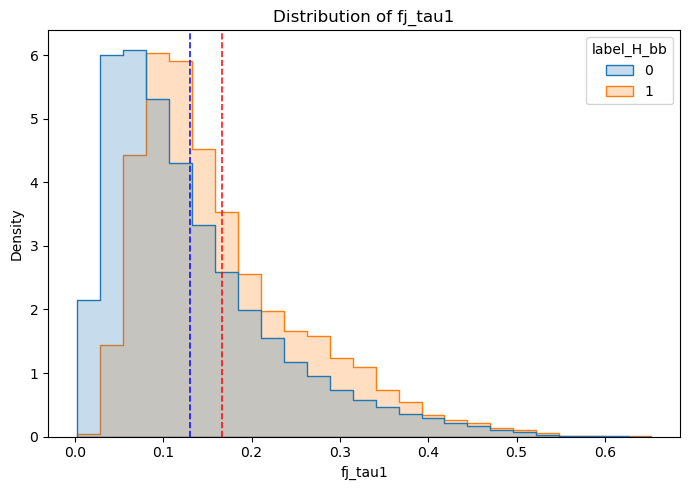

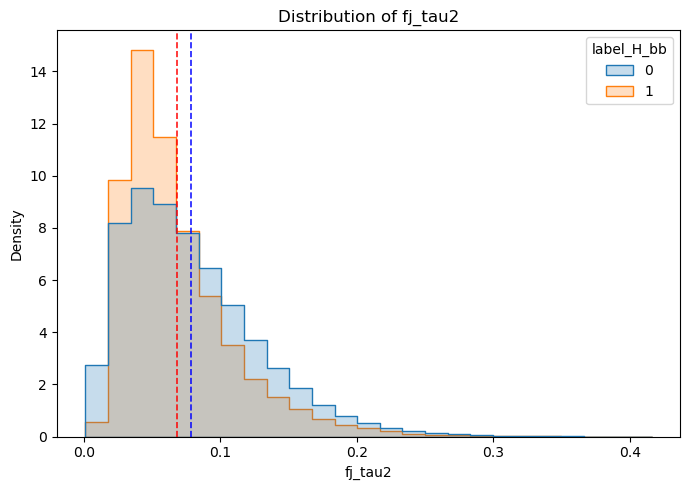

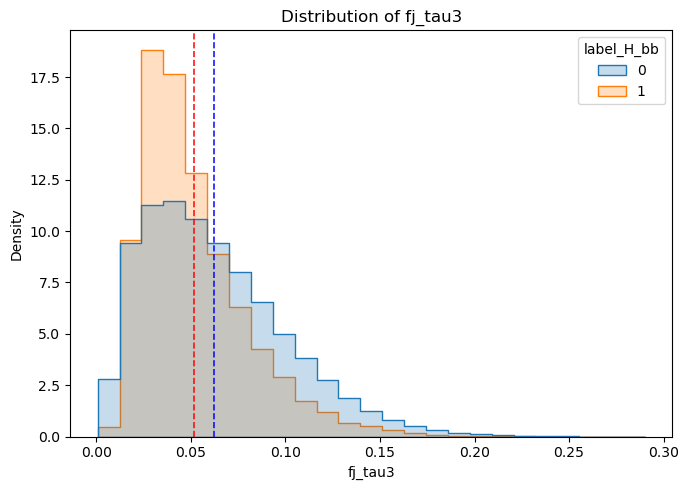

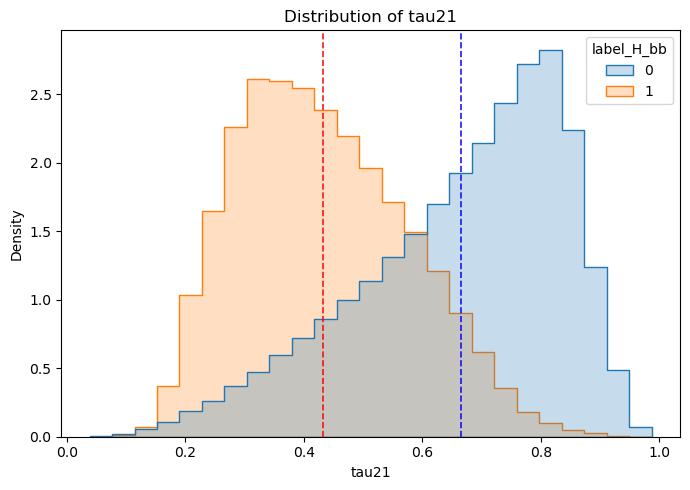

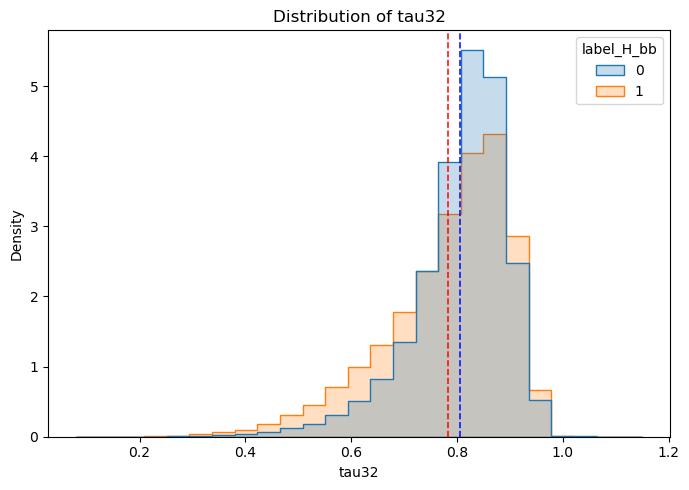

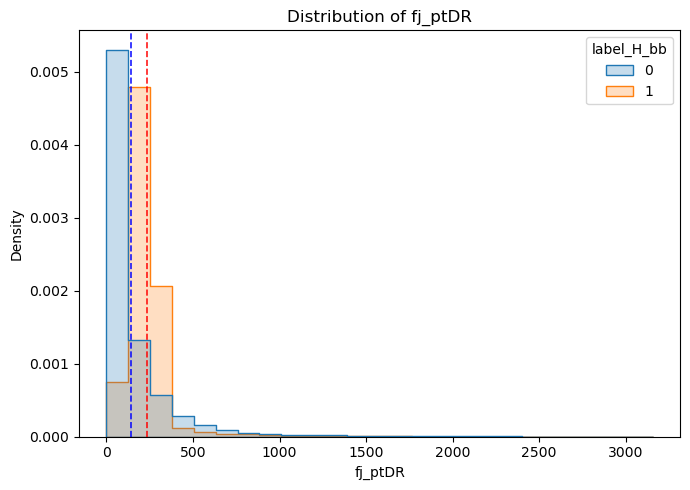

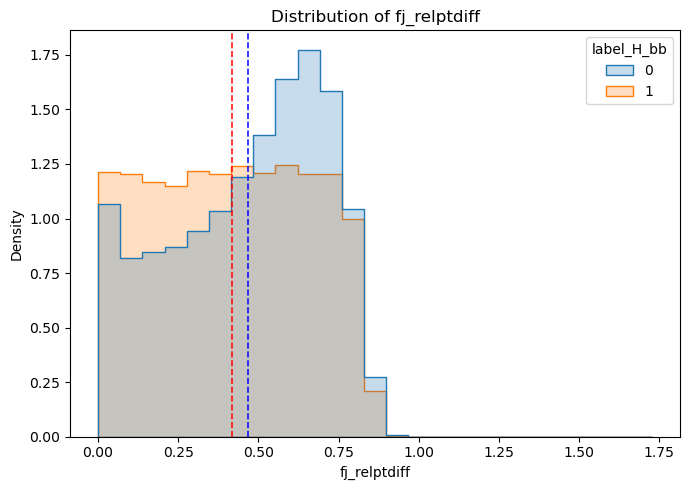

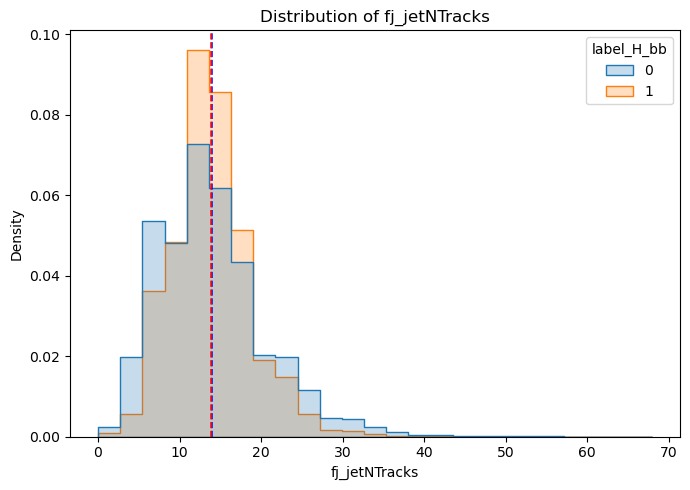

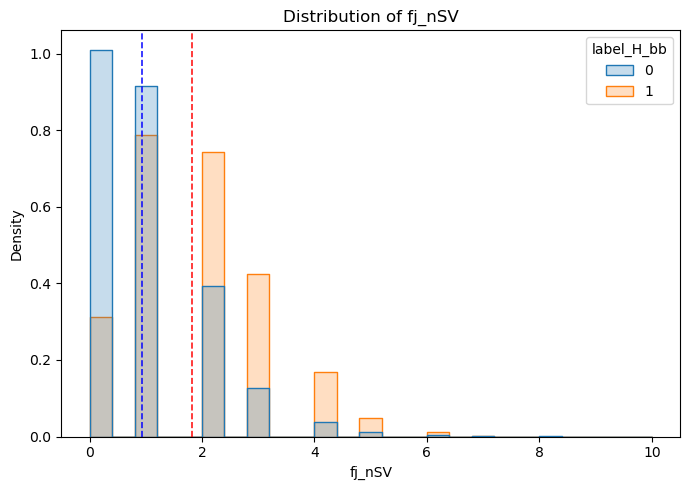

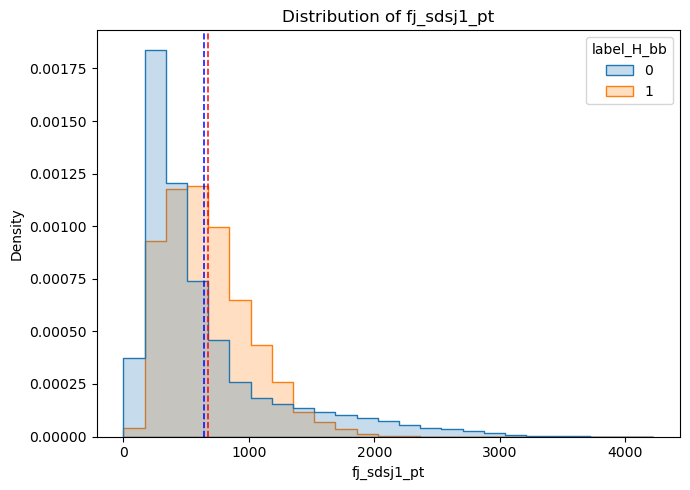

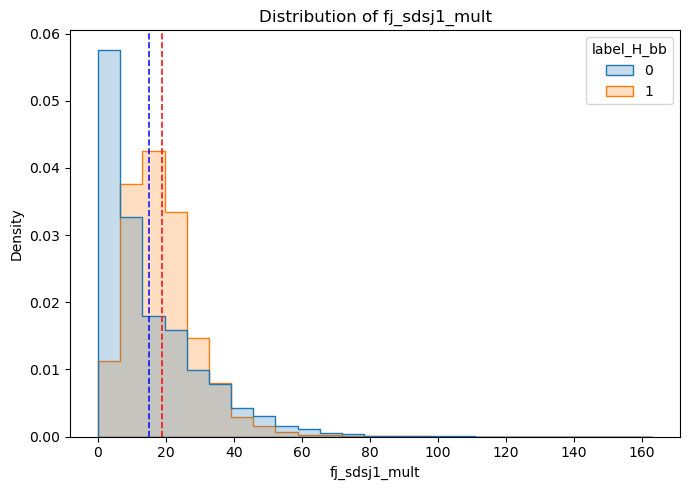

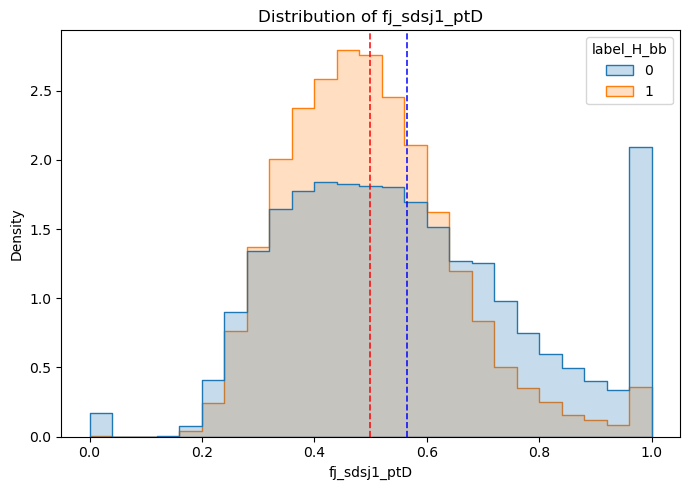

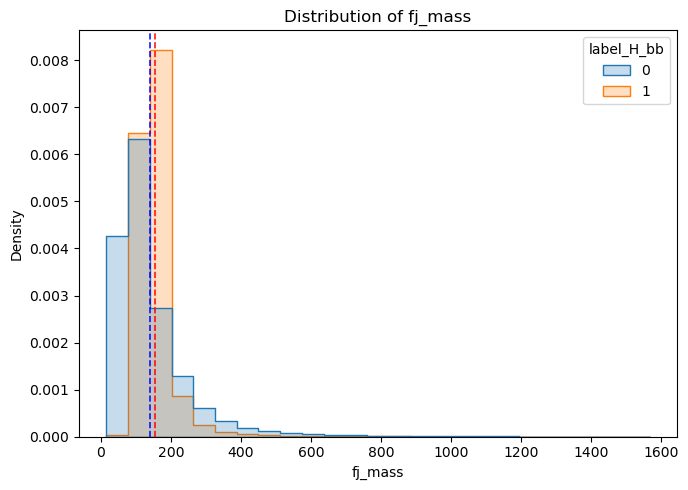

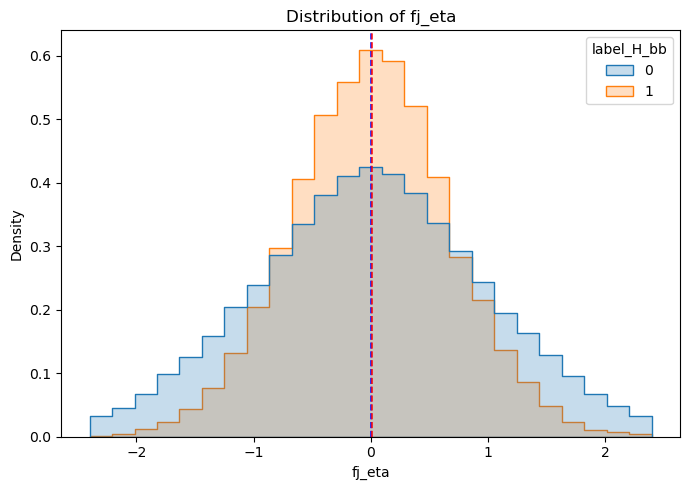

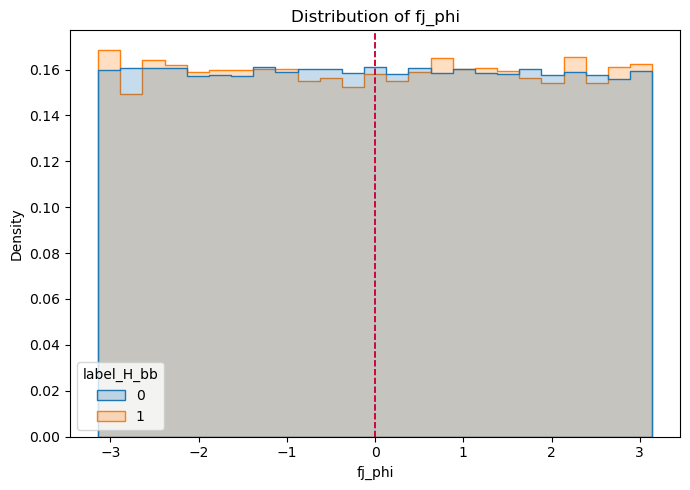

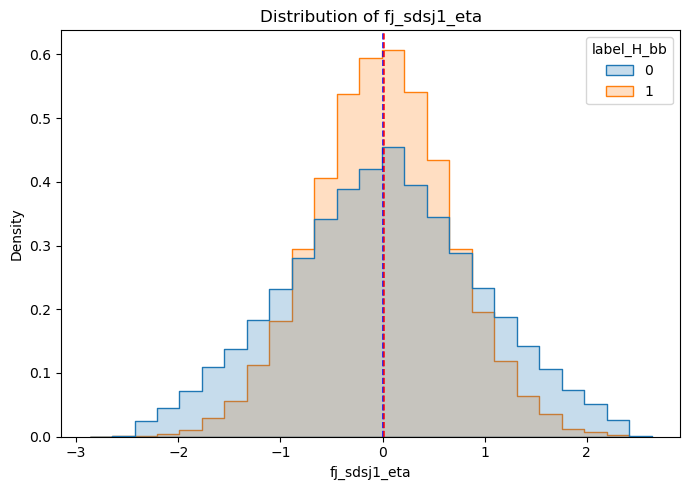

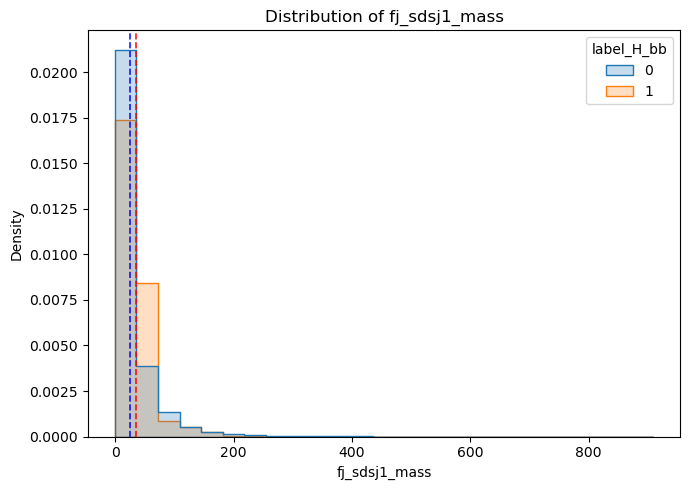

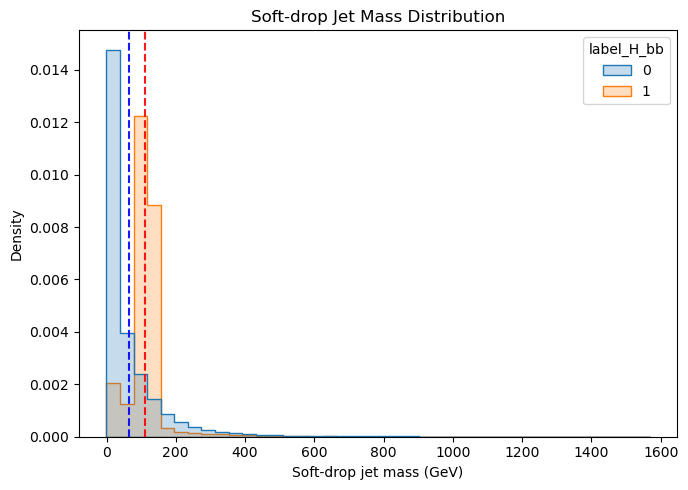

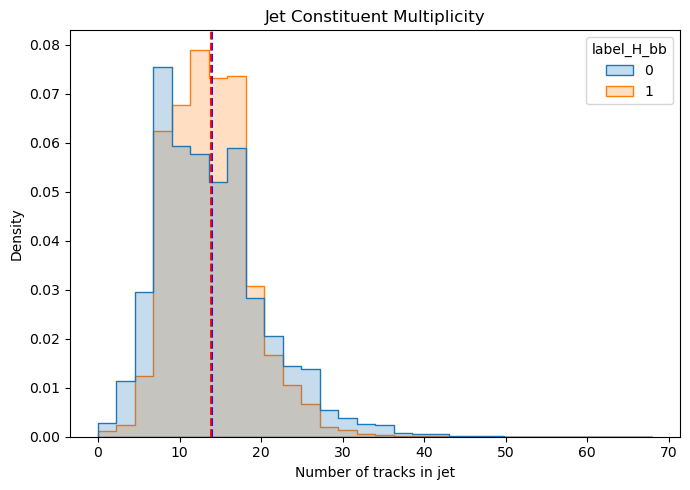

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Basic dataset overview
# -------------------------
df.info()
display(df.describe().T)

print("\nLabel counts:")
print(df[label_col].value_counts())

print("\nLabel proportions:")
print(df[label_col].value_counts(normalize=True))


# -------------------------
# Feature list
# -------------------------
feature_cols = [
    "fj_pt",
    "fj_sdmass",
    "fj_sdn2",
    "fj_n_sdsubjets",
    "fj_tau1",
    "fj_tau2",
    "fj_tau3",
    "tau21",
    "tau32",
    "fj_ptDR",
    "fj_relptdiff",
    "fj_jetNTracks",
    "fj_nSV",
    "fj_sdsj1_pt",
    "fj_sdsj1_mult",
    "fj_sdsj1_ptD",
    "fj_mass",
    "fj_eta",
    "fj_phi",
    "fj_sdsj1_eta",
    "fj_sdsj1_mass"
]

label_col = "label_H_bb"


for col in feature_cols:
    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x=col,
        hue=label_col,
        bins=25,
        stat="density",
        element="step",
        common_norm=False
    )

    # Mean lines (BLUE = background, RED = signal)
    for lbl, color in zip([0, 1], ["blue", "red"]):
        plt.axvline(
            df.loc[df[label_col] == lbl, col].mean(),
            linestyle="--",
            color=color,
            linewidth=1.2,
            alpha=0.9
        )

    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="fj_sdmass",
    hue=label_col,
    bins=40,
    stat="density",
    element="step",
    common_norm=False
)

for lbl, color in zip([0, 1], ["blue", "red"]):
    plt.axvline(
        df.loc[df[label_col] == lbl, "fj_sdmass"].mean(),
        linestyle="--",
        color=color,
        linewidth=1.5,
        alpha=0.9
    )

plt.xlabel("Soft-drop jet mass (GeV)")
plt.ylabel("Density")
plt.title("Soft-drop Jet Mass Distribution")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="fj_jetNTracks",
    hue=label_col,
    bins=30,
    stat="density",
    element="step",
    common_norm=False
)

for lbl, color in zip([0, 1], ["blue", "red"]):
    plt.axvline(
        df.loc[df[label_col] == lbl, "fj_jetNTracks"].mean(),
        linestyle="--",
        color=color,
        linewidth=1.5,
        alpha=0.9
    )

plt.xlabel("Number of tracks in jet")
plt.ylabel("Density")
plt.title("Jet Constituent Multiplicity")
plt.tight_layout()
plt.show()


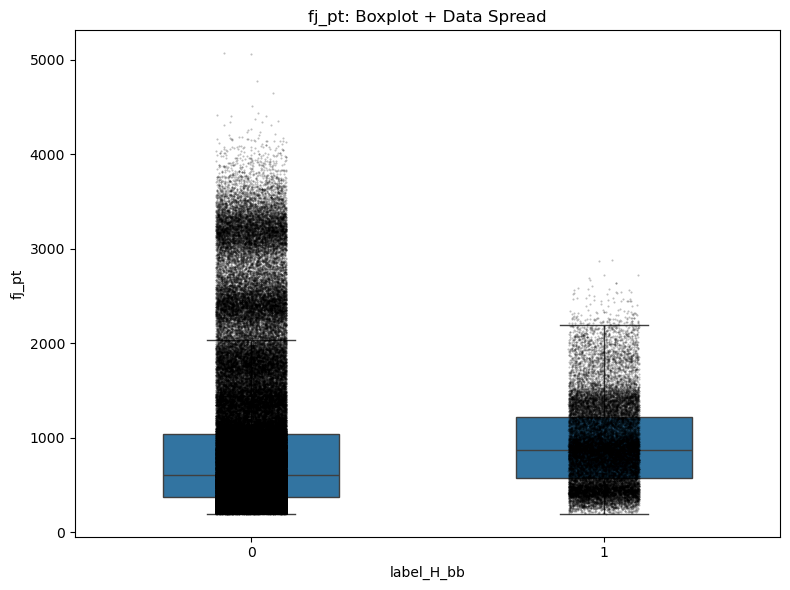

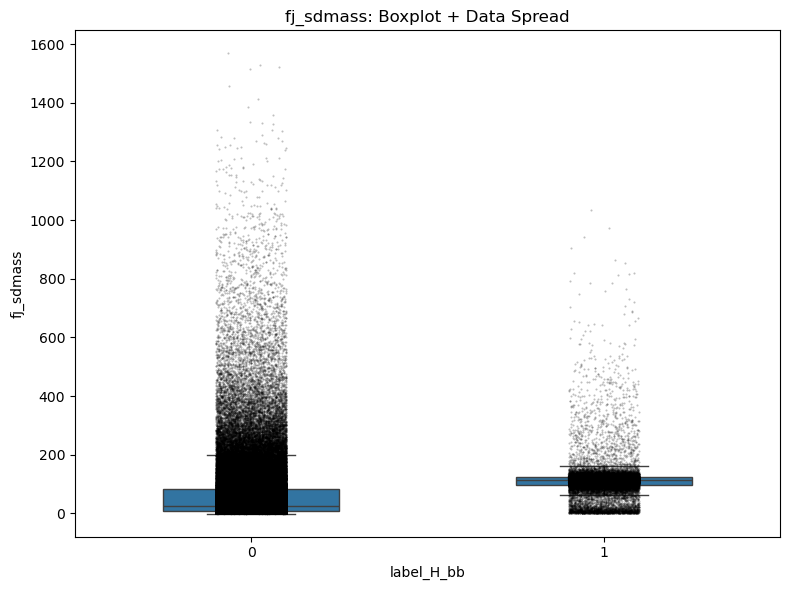

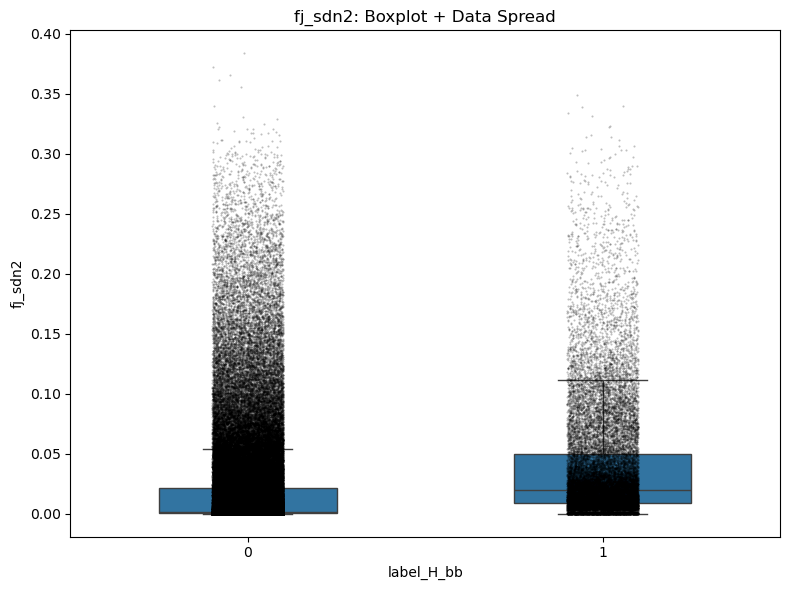

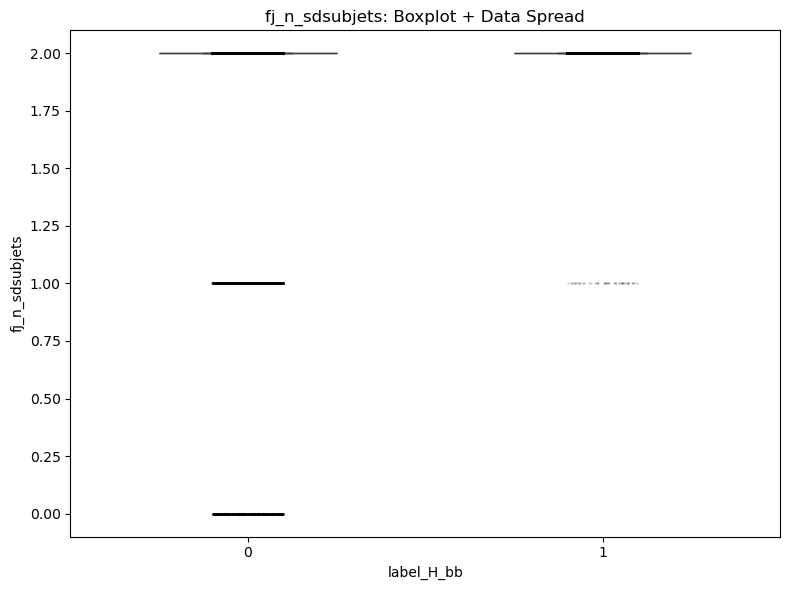

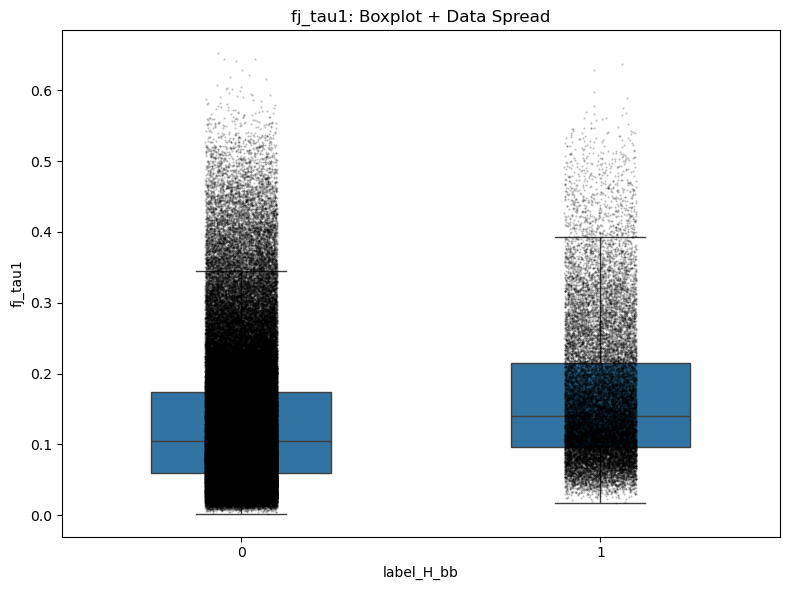

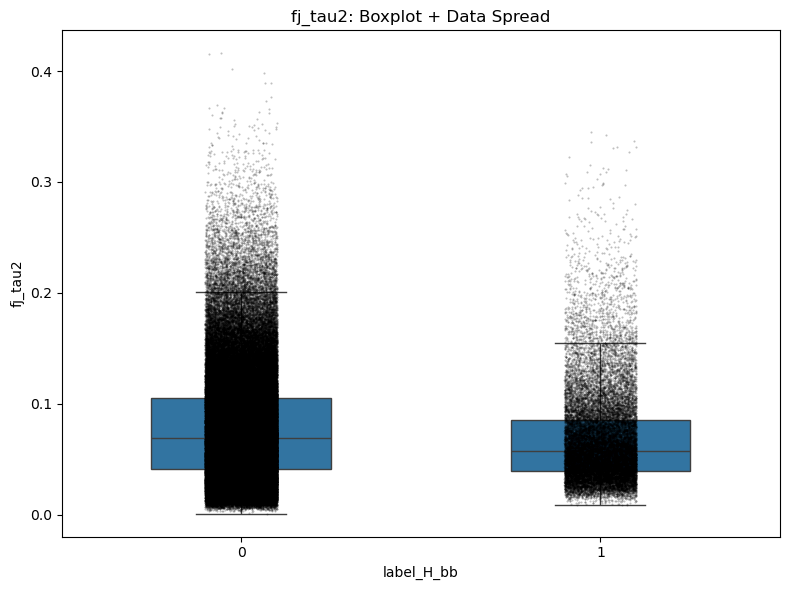

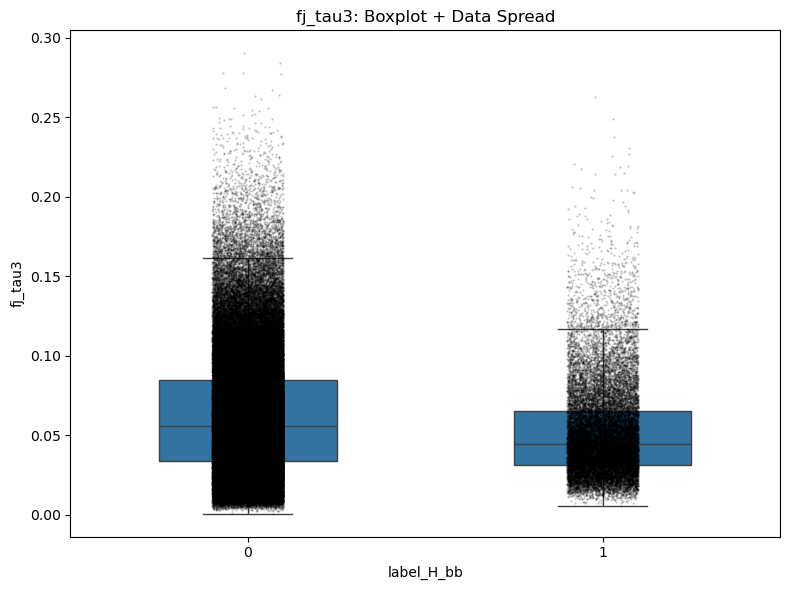

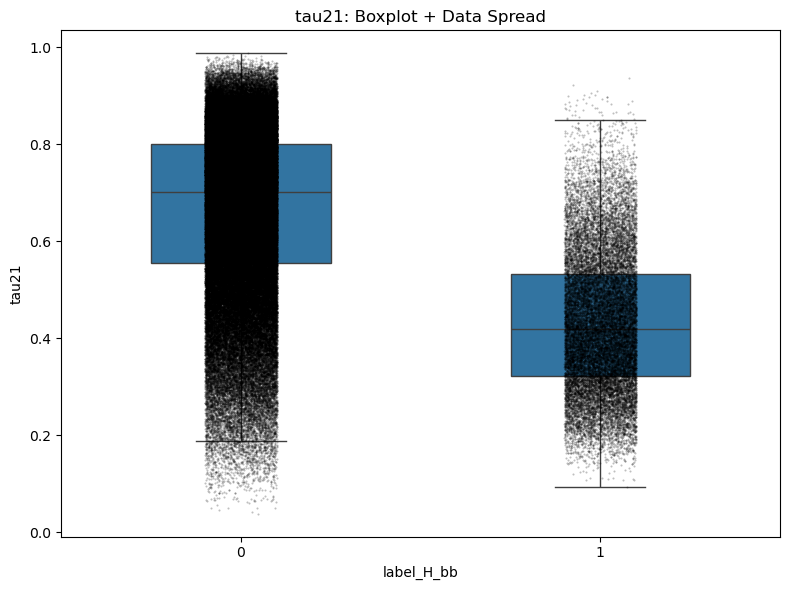

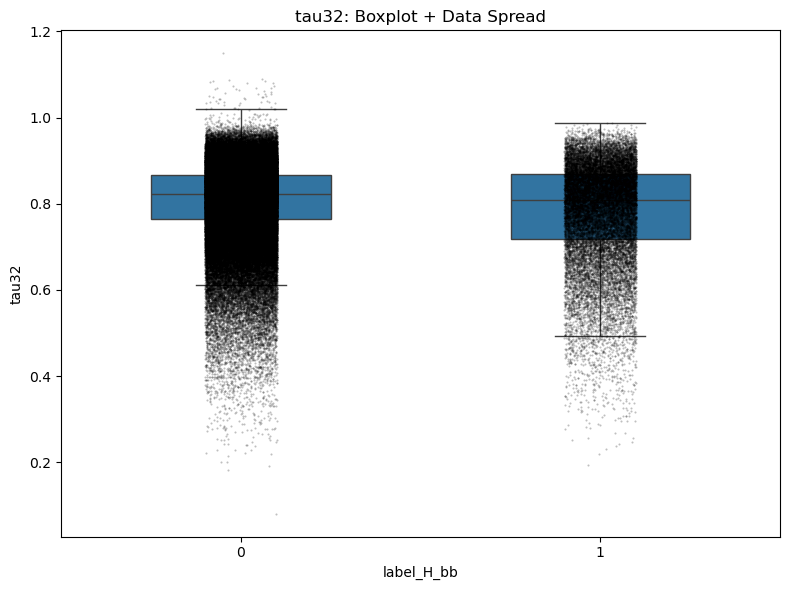

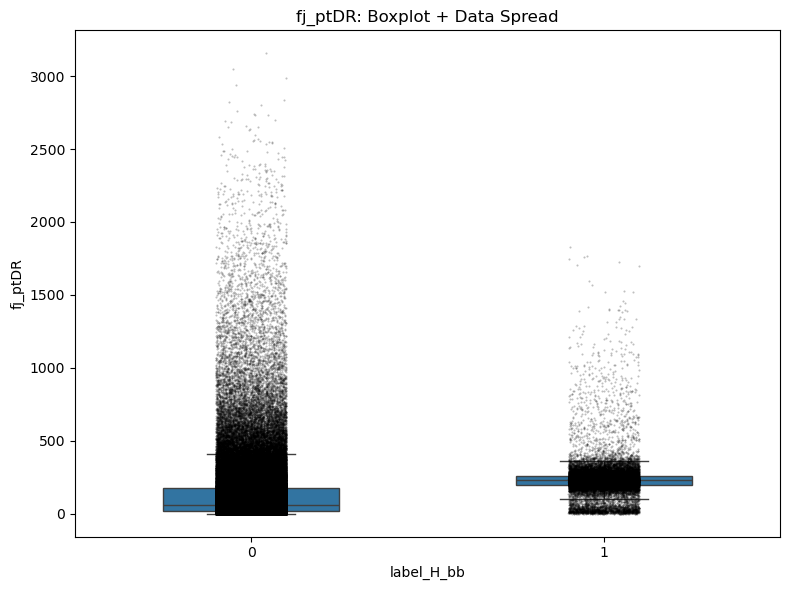

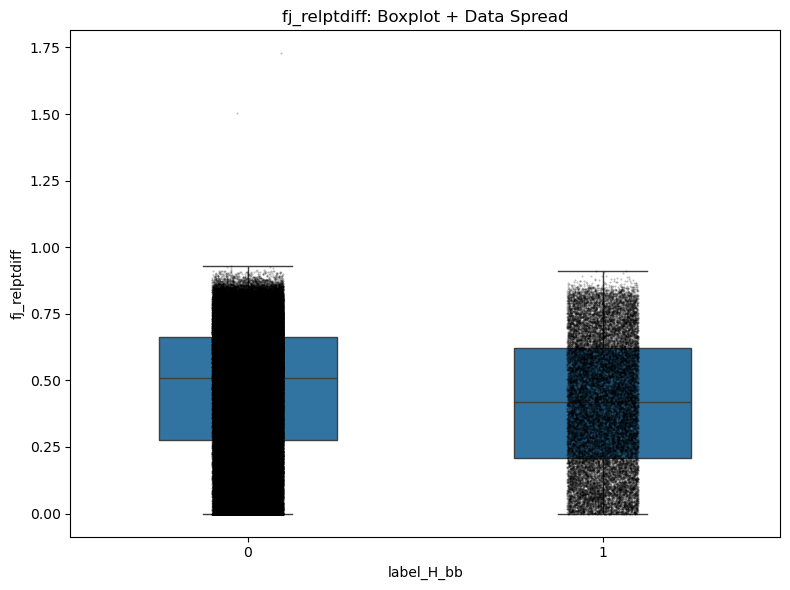

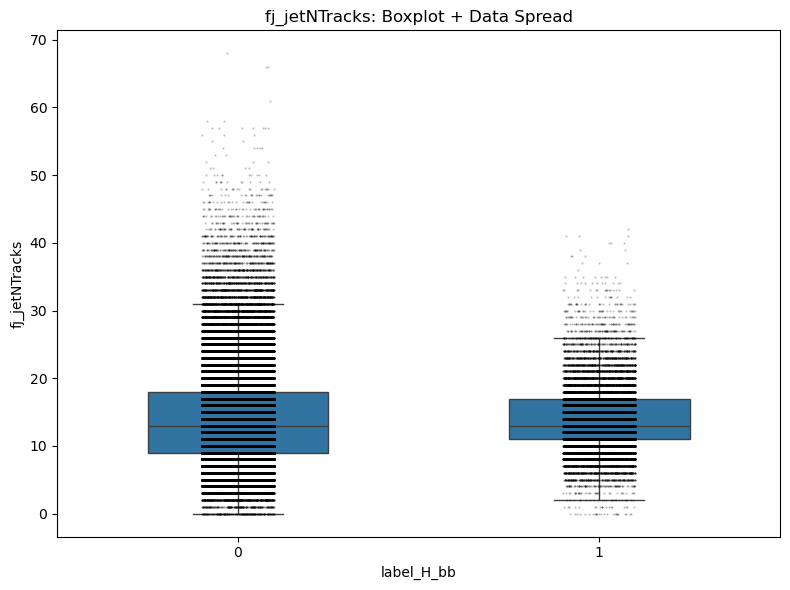

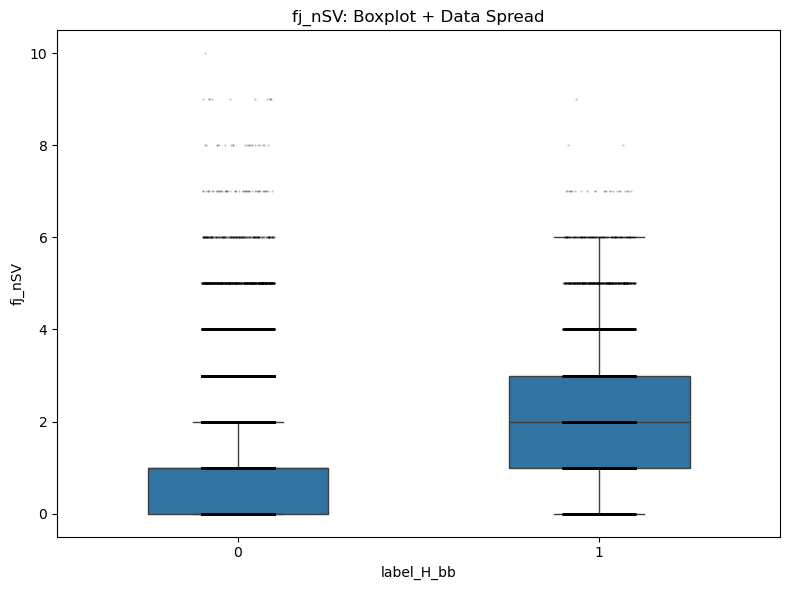

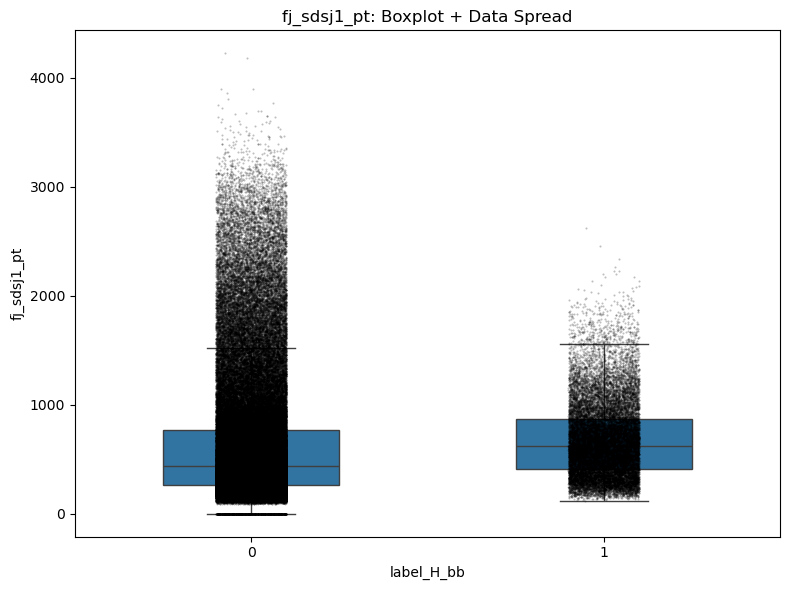

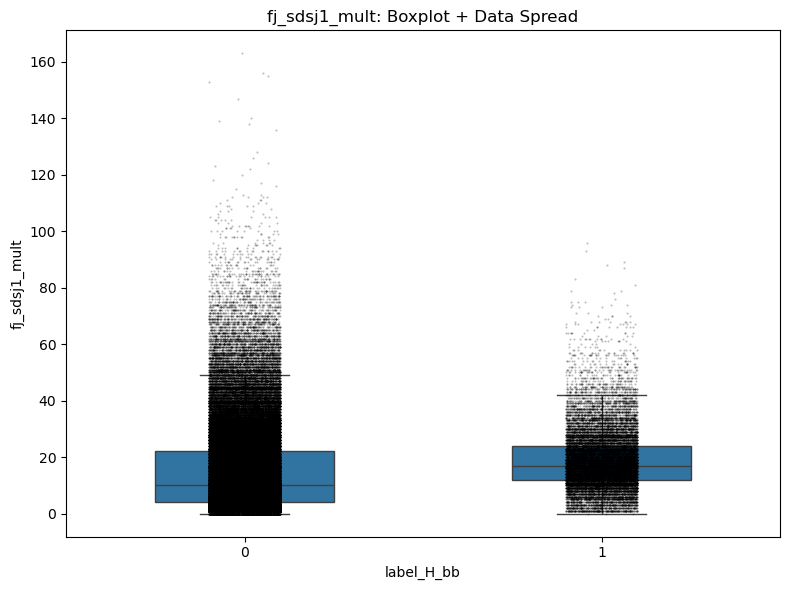

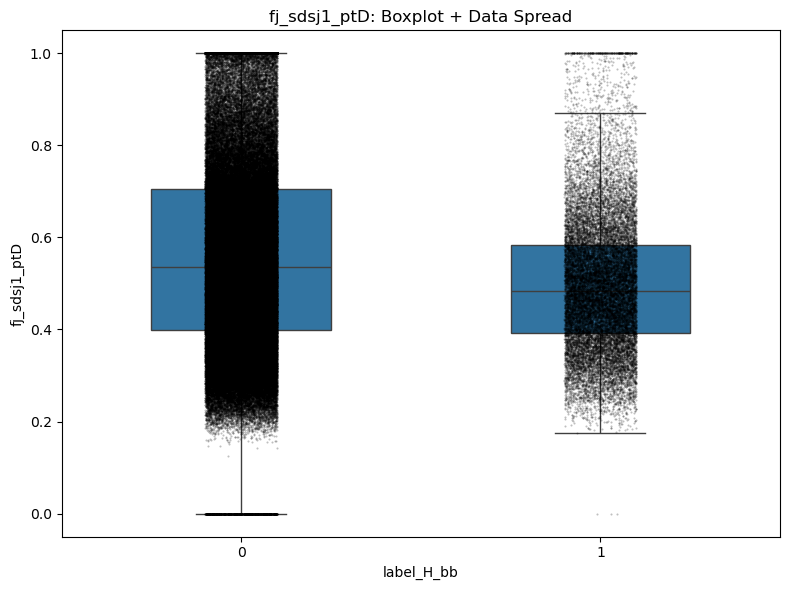

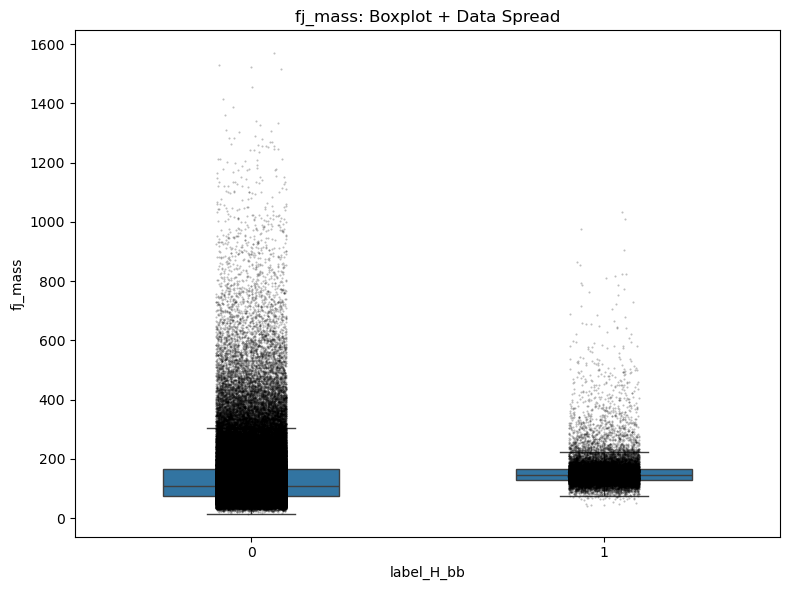

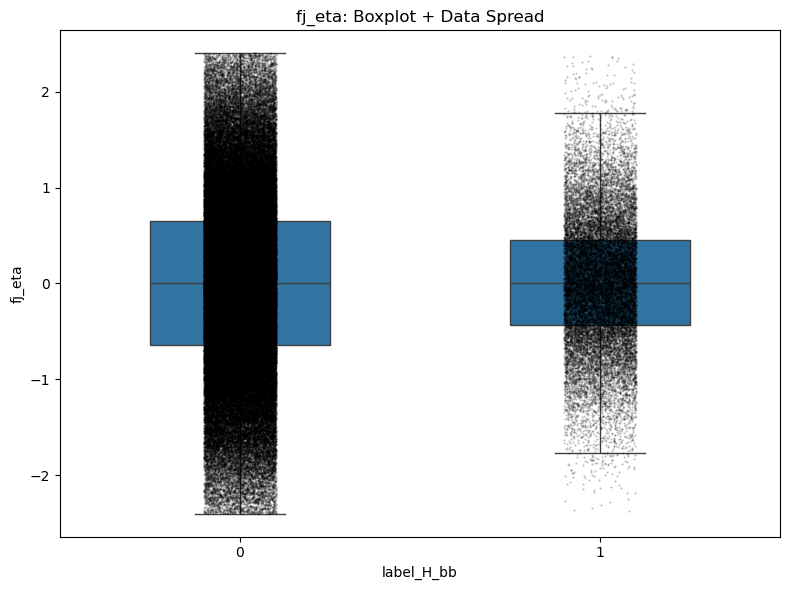

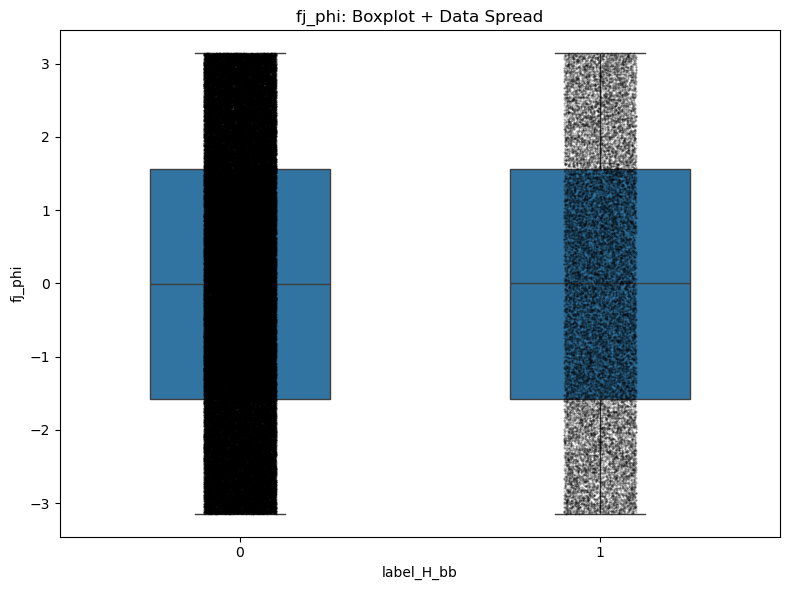

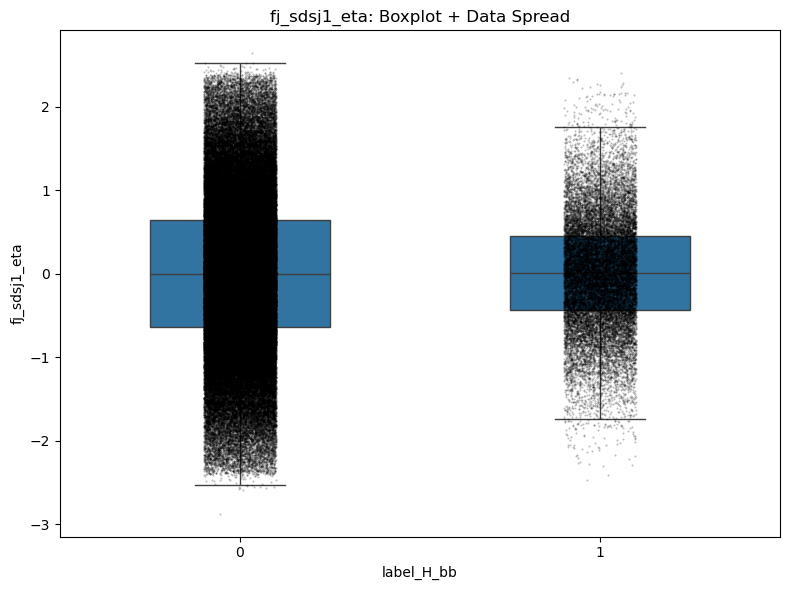

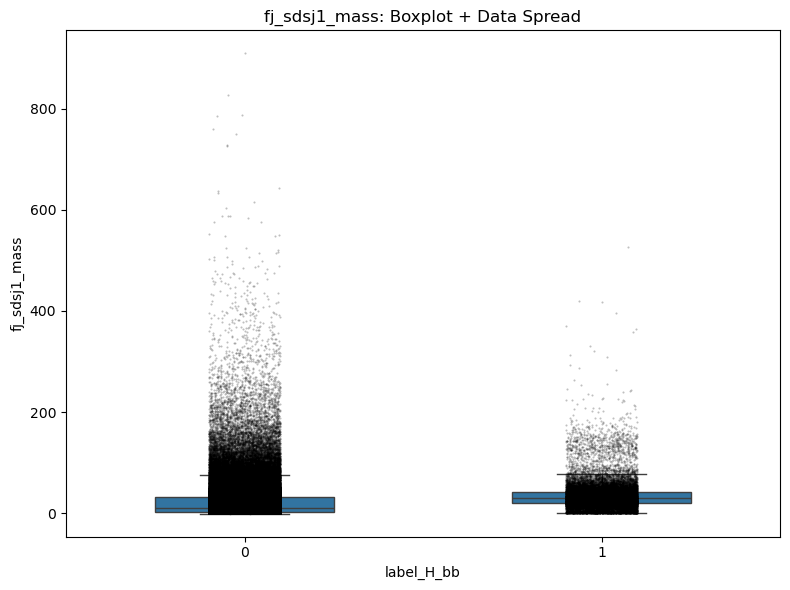

In [ ]:


for col in feature_cols:
    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=df,
        x=label_col,
        y=col,
        showfliers=False,          
        width=0.5
    )

    sns.stripplot(
        data=df,
        x=label_col,
        y=col,
        color="black",
        size=1.5,
        alpha=0.25,
        jitter=True
    )

    plt.title(f"{col}: Boxplot + Data Spread")
    plt.tight_layout()
    plt.show()


Top features used for bivariate EDA:
  • fj_pt
  • fj_sdmass
  • fj_nSV
  • fj_tau1
  • fj_tau2
  • fj_sdsj1_ptD
----------------------------------------------------------------------


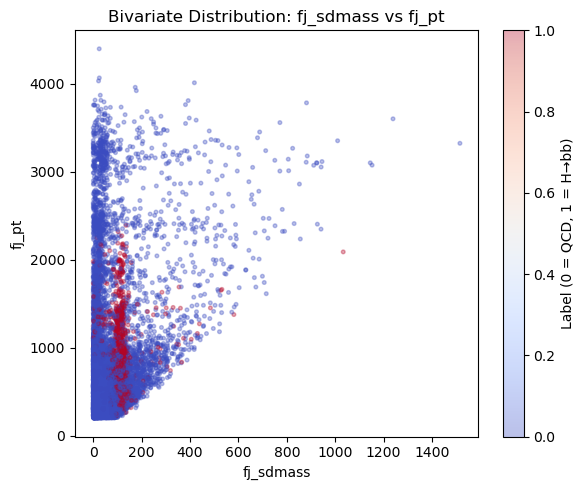

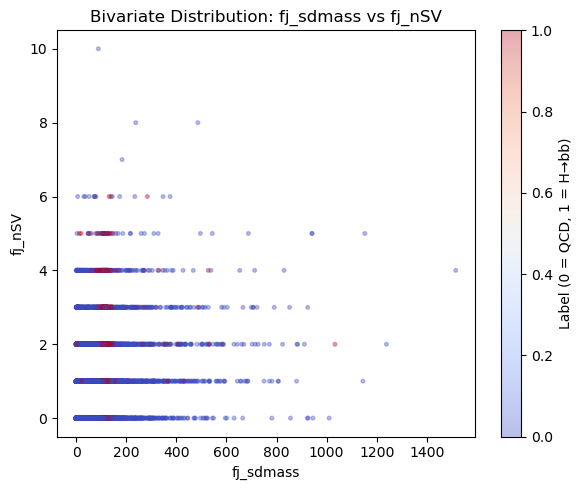

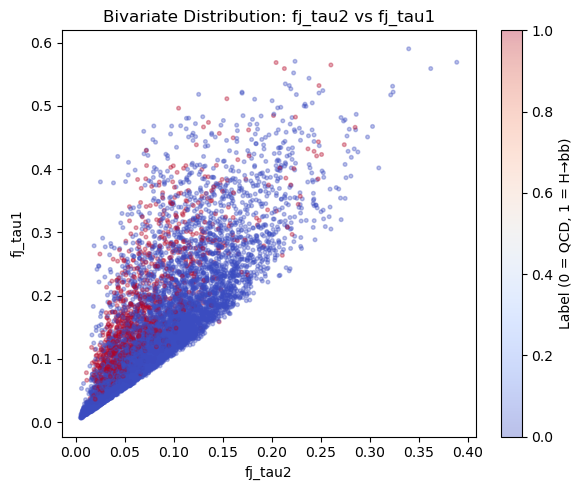

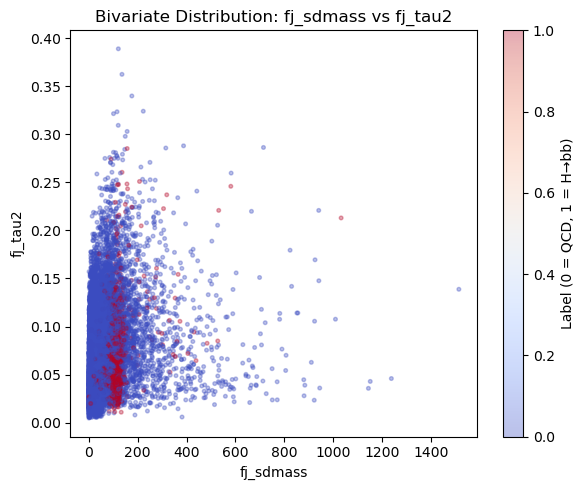

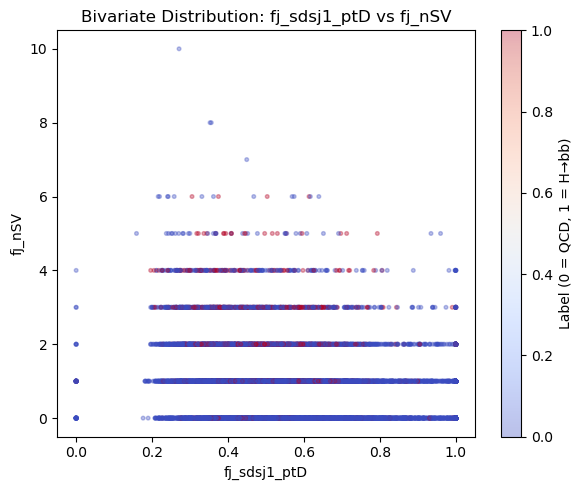

Computing Spearman correlation between top features...


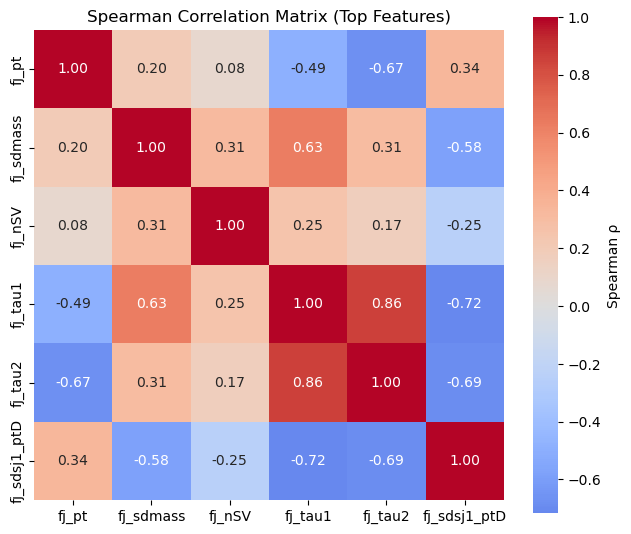


Highly correlated feature pairs (|ρ| > 0.8):
  • fj_tau2  <-->  fj_tau1 : 0.86


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label = label_col
sample_size = 10000
random_state = 42

# Physics-motivated top features (NOT feature_cols[:6])
top_features = [
    "fj_pt",            # jet kinematics
    "fj_sdmass",        # groomed jet mass
    "fj_nSV",           # b-hadron decay proxy
    "fj_tau1",          # substructure
    "fj_tau2",          # substructure
    "fj_sdsj1_ptD"      # subjet internal structure
]

print("Top features used for bivariate EDA:")
for f in top_features:
    print(f"  • {f}")
print("-" * 70)

df_plot = df.sample(
    n=min(sample_size, len(df)),
    random_state=random_state
)

selected_pairs = [
    ("fj_sdmass", "fj_pt"),          # mass vs boost
    ("fj_sdmass", "fj_nSV"),         # Higgs vs QCD signature
    ("fj_tau2", "fj_tau1"),          # 2-prong vs 1-prong
    ("fj_sdmass", "fj_tau2"),        # mass–substructure interplay
    ("fj_sdsj1_ptD", "fj_nSV")       # subjet structure vs b-tag proxy
]

for f1, f2 in selected_pairs:

    if f1 not in df_plot.columns or f2 not in df_plot.columns:
        print(f"Skipping missing pair: ({f1}, {f2})")
        continue

    plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        df_plot[f1],
        df_plot[f2],
        c=df_plot[label],
        cmap="coolwarm",
        s=7,
        alpha=0.35
    )

    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f"Bivariate Distribution: {f1} vs {f2}")

    cbar = plt.colorbar(sc)
    cbar.set_label("Label (0 = QCD, 1 = H→bb)")

    plt.tight_layout()
    plt.show()

print("Computing Spearman correlation between top features...")

corr = df[top_features].corr(method="spearman")

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Spearman ρ"}
)

plt.title("Spearman Correlation Matrix (Top Features)")
plt.tight_layout()
plt.show()


threshold = 0.8
print(f"\nHighly correlated feature pairs (|ρ| > {threshold}):")

found = False
for i in range(1, len(corr.columns)):
    for j in range(i):
        rho = corr.iloc[i, j]
        if abs(rho) > threshold:
            found = True
            print(
                f"  • {corr.columns[i]}  <-->  {corr.columns[j]} : {rho:.2f}"
            )

if not found:
    print("  None")


Top features used for bivariate EDA:
  • fj_pt
  • fj_sdmass
  • fj_nSV
  • fj_tau1
  • fj_tau2
  • fj_sdsj1_ptD
----------------------------------------------------------------------


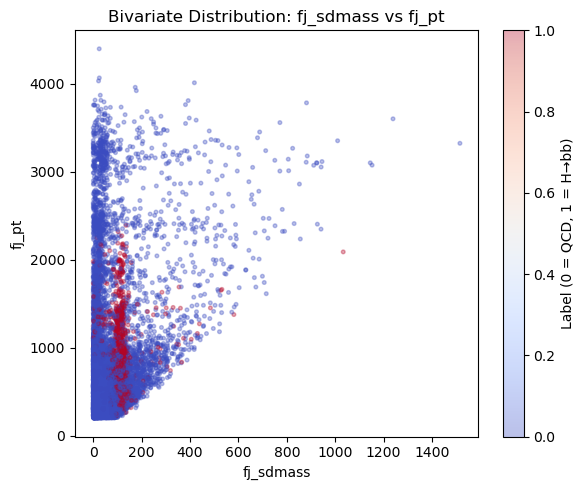

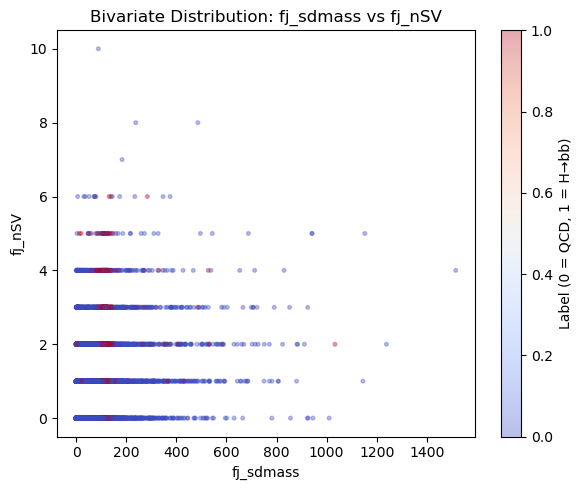

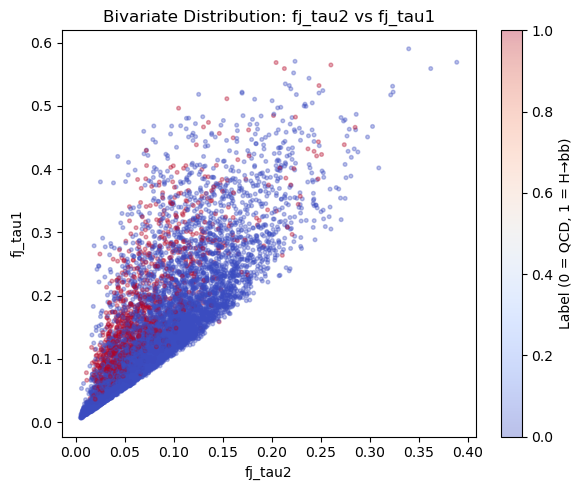

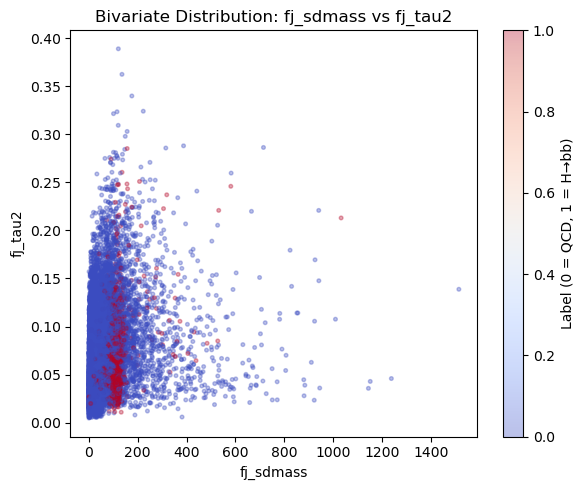

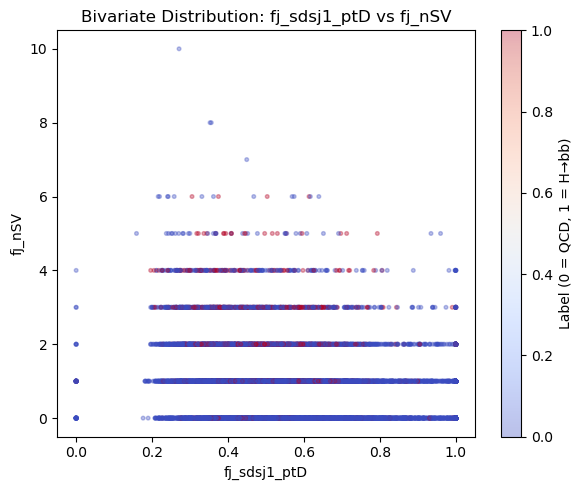

Computing Spearman correlation between top features...


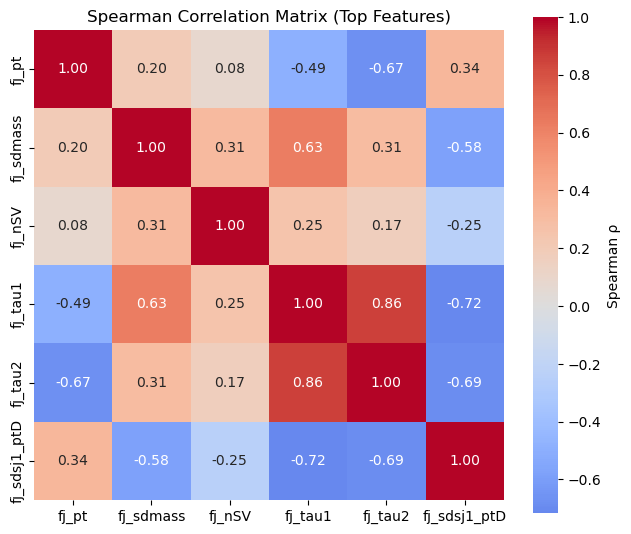


Highly correlated feature pairs (|ρ| > 0.8):
  • fj_tau2  <-->  fj_tau1 : 0.86


In [16]:
from scipy.stats import ks_2samp

ks_results = []

for col in feature_cols:
    sig = df.loc[df[label_col] == 1, col].dropna()
    bkg = df.loc[df[label_col] == 0, col].dropna()

    ks_stat, _ = ks_2samp(sig, bkg)

    ks_results.append({
        "feature": col,
        "ks": ks_stat
    })

ks_df = (
    pd.DataFrame(ks_results)
    .sort_values("ks", ascending=False)
    .reset_index(drop=True)
)

display(ks_df)


,feature,ks
0,fj_sdmass,0.606585
1,fj_ptDR,0.600912
2,tau21,0.545917
3,fj_sdn2,0.463712
4,fj_mass,0.459075
5,fj_sdsj1_mass,0.443128
6,fj_sdsj1_mult,0.335394
7,fj_nSV,0.330393
8,fj_pt,0.230287
9,fj_sdsj1_pt,0.223018


In [17]:
DROP_NOW = ["fj_n_sdsubjets", "fj_phi"]


In [18]:
keep_ks = [
    "fj_sdmass", "fj_ptDR", "tau21", "fj_sdn2", "fj_mass",
    "fj_sdsj1_mass", "fj_sdsj1_mult", "fj_nSV", "fj_pt",
    "fj_sdsj1_pt", "fj_tau1", "fj_sdsj1_ptD", "fj_tau3",
    "fj_tau2", "fj_relptdiff", "tau32", "fj_jetNTracks",
    "fj_eta", "fj_sdsj1_eta"
]

corr = df[keep_ks].corr(method="spearman")

CORR_MAX = 0.85
to_drop = set()

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > CORR_MAX:
            f1 = corr.columns[i]
            f2 = corr.columns[j]

            ks1 = ks_df.loc[ks_df.feature == f1, "ks"].values[0]
            ks2 = ks_df.loc[ks_df.feature == f2, "ks"].values[0]

            drop = f1 if ks1 < ks2 else f2
            to_drop.add(drop)

final_features = [f for f in keep_ks if f not in to_drop]

print("Dropped due to correlation:", list(to_drop))
print("FINAL FEATURES:", final_features)


Dropped due to correlation: ['fj_ptDR', 'fj_sdsj1_pt', 'fj_sdsj1_eta', 'fj_sdsj1_mult', 'fj_sdn2', 'fj_sdsj1_mass', 'fj_tau2']
FINAL FEATURES: ['fj_sdmass', 'tau21', 'fj_mass', 'fj_nSV', 'fj_pt', 'fj_tau1', 'fj_sdsj1_ptD', 'fj_tau3', 'fj_relptdiff', 'tau32', 'fj_jetNTracks', 'fj_eta']


In [19]:
from sklearn.model_selection import train_test_split

X = df[final_features]
y = df[label_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [20]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)


In [23]:
import os
import numpy as np
import joblib

BASE_PATH = r"C:\Users\Agastya\Hbb-jet-tagging"

DATA_PROCESSED = os.path.join(BASE_PATH, "data", "processed")
ARTIFACTS_DIR  = os.path.join(BASE_PATH, "artifacts")

os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

np.savez(
    os.path.join(DATA_PROCESSED, "train.npz"),
    X=X_train_scaled,
    y=y_train.values
)

np.savez(
    os.path.join(DATA_PROCESSED, "val.npz"),
    X=X_val_scaled,
    y=y_val.values
)

joblib.dump(
    scaler,
    os.path.join(ARTIFACTS_DIR, "scaler.pkl")
)

print("✅ Files saved to data/processed and artifacts")


✅ Files saved to data/processed and artifacts


In [1]:
import uproot
import pandas as pd
import numpy as np
import os

# -------------------------
# Paths
# -------------------------
TEST_ROOT = r"C:\Users\Agastya\Hbb-jet-tagging\data\raw\test_root_file.root"
OUT_PARQUET = r"C:\Users\Agastya\Hbb-jet-tagging\data\processed\test.parquet"

os.makedirs(r"C:\Users\Agastya\Hbb-jet-tagging\data\processed", exist_ok=True)

# -------------------------
# Features (MUST MATCH TRAIN)
# -------------------------
feature_cols = [
    "fj_pt",
    "fj_sdmass",
    "fj_sdn2",
    "fj_n_sdsubjets",
    "fj_tau1",
    "fj_tau2",
    "fj_tau3",
    "fj_ptDR",
    "fj_relptdiff",
    "fj_jetNTracks",
    "fj_nSV",
    "fj_sdsj1_pt",
    "fj_sdsj1_mult",
    "fj_sdsj1_ptD",
    "fj_mass",
    "fj_eta",
    "fj_phi",
    "fj_sdsj1_eta",
    "fj_sdsj1_mass"
]

# -------------------------
# Load ROOT
# -------------------------
file = uproot.open(TEST_ROOT)
tree = file["deepntuplizer/tree;41"]  # adjust cycle only if needed

arrays = tree.arrays(feature_cols, library="np")
df_test = pd.DataFrame(arrays)

# -------------------------
# Feature engineering (SAME AS TRAIN)
# -------------------------
df_test["tau21"] = df_test["fj_tau2"] / df_test["fj_tau1"]
df_test["tau32"] = df_test["fj_tau3"] / df_test["fj_tau2"]

# -------------------------
# Basic cleanup
# -------------------------
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)
df_test.reset_index(drop=True, inplace=True)

# -------------------------
# Save parquet
# -------------------------
df_test.to_parquet(OUT_PARQUET)

print("✅ test.parquet saved at:")
print(OUT_PARQUET)
print("Shape:", df_test.shape)


✅ test.parquet saved at:
C:\Users\Agastya\Hbb-jet-tagging\data\processed\test.parquet
Shape: (199711, 21)
